# EDA

Exploration, statistiques descriptives, visualisations, analyse du déséquilibre, conclusions.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parents[0]
sys.path.append(str(ROOT / 'src'))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats

from data.download import download_raw_dataset
from data.validate import validate_dataset

sns.set_theme(style="whitegrid")


In [7]:
#csv_path = download_raw_dataset()
csv_path = Path("/home/narcisse/Projets/detecter-fraude-bancaire/data/raw/creditcard.csv")
metadata = validate_dataset(csv_path)


In [8]:
df = pd.read_csv(csv_path)
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [9]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [10]:
df.isna().sum().sort_values(ascending=False).head()


Time    0
V1      0
V2      0
V3      0
V4      0
dtype: int64

In [11]:
duplicates = df.duplicated().sum()
duplicates


np.int64(1081)

In [12]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [13]:
class_counts = df['Class'].value_counts()
class_pct = df['Class'].value_counts(normalize=True)
base_rate = class_pct.get(1, 0.0)
class_counts, class_pct, base_rate


(Class
 0    284315
 1       492
 Name: count, dtype: int64,
 Class
 0    0.998273
 1    0.001727
 Name: proportion, dtype: float64,
 np.float64(0.001727485630620034))

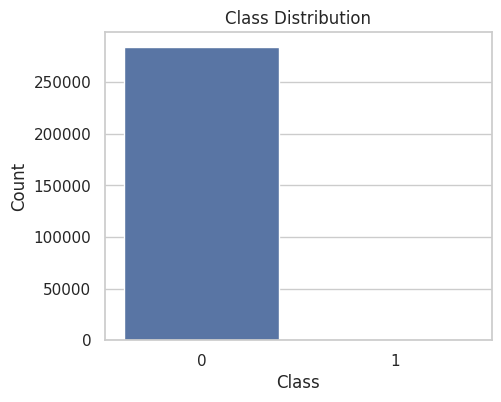

In [14]:
plt.figure(figsize=(5,4))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()


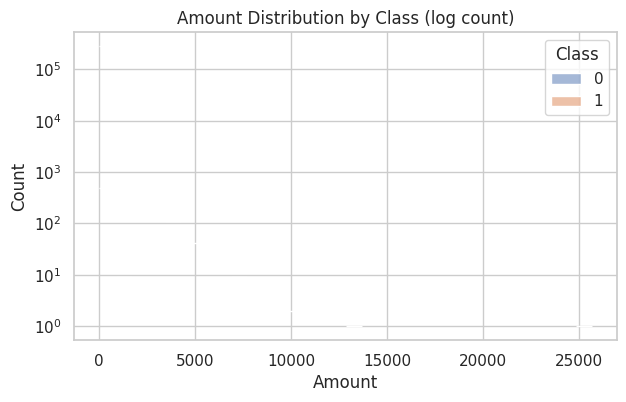

In [15]:
plt.figure(figsize=(7,4))
sns.histplot(data=df, x='Amount', hue='Class', bins=30, log_scale=(False, True))
plt.title('Amount Distribution by Class (log count)')
plt.show()


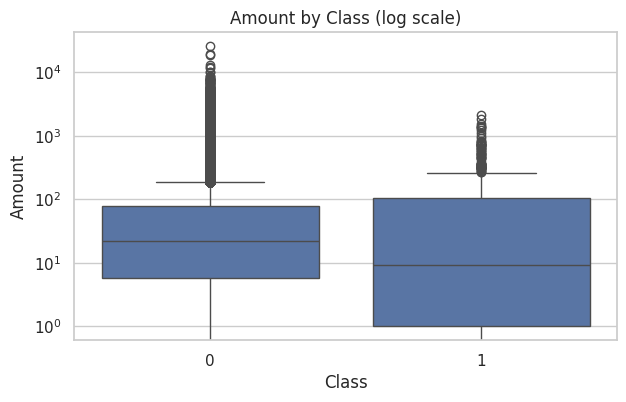

In [16]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x='Class', y='Amount')
plt.yscale('log')
plt.title('Amount by Class (log scale)')
plt.show()


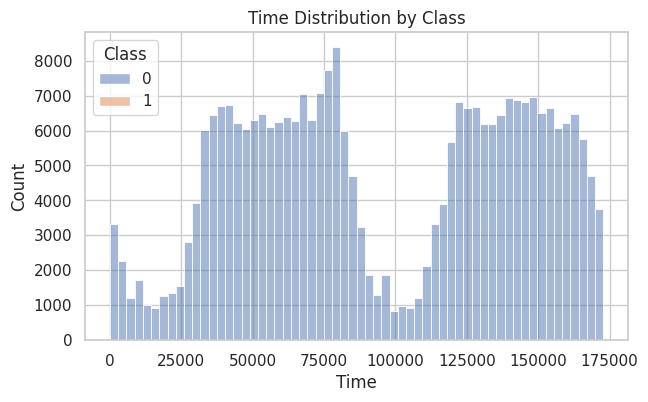

In [17]:
plt.figure(figsize=(7,4))
sns.histplot(data=df, x='Time', hue='Class', bins=60)
plt.title('Time Distribution by Class')
plt.show()


In [18]:
corr_with_target = df.corr(numeric_only=True)['Class'].sort_values()
corr_with_target.head(10), corr_with_target.tail(10)


(V17   -0.326481
 V14   -0.302544
 V12   -0.260593
 V10   -0.216883
 V16   -0.196539
 V3    -0.192961
 V7    -0.187257
 V18   -0.111485
 V1    -0.101347
 V9    -0.097733
 Name: Class, dtype: float64,
 V28      0.009536
 V27      0.017580
 V8       0.019875
 V20      0.020090
 V19      0.034783
 V21      0.040413
 V2       0.091289
 V4       0.133447
 V11      0.154876
 Class    1.000000
 Name: Class, dtype: float64)

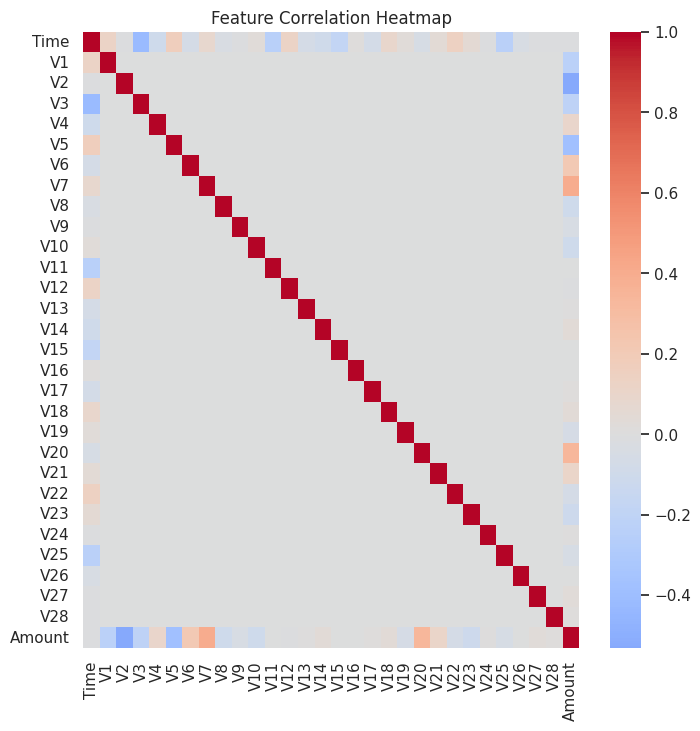

In [19]:
corr = df.drop(columns=['Class']).corr()
plt.figure(figsize=(8,8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()


In [20]:
fraud = df[df['Class'] == 1]['Amount']
non_fraud = df[df['Class'] == 0]['Amount']
stat, pvalue = stats.mannwhitneyu(fraud, non_fraud, alternative='two-sided')
stat, pvalue


(np.float64(61833399.0), np.float64(8.578472310840218e-06))

## Conclusions

- Dataset fortement déséquilibré: la classe fraude est minoritaire.
- Les distributions `Amount` et `Time` montrent des patterns utiles.
- Les variables `V*` sont déjà anonymisées (PCA).
- Les tests non paramétriques indiquent une différence de distribution sur `Amount`.
